In [ ]:
# import os

# Optional Kaggle setup for Google Colab. Keep credentials in the standard ~/.kaggle directory and outside Git.
# 1. Prompt a secure file upload widget in the browser
# from google.colab import files
# uploaded = files.upload()

# 2. Securely move the uploaded file into the correct hidden folder
# if 'kaggle.json' in uploaded:
#     !mkdir -p ~/.kaggle
#     !mv kaggle.json ~/.kaggle/
    
#     # 3. Apply the exact permission restriction required by Kaggle
#     !chmod 600 ~/.kaggle/kaggle.json
#     print("Kaggle API token configured successfully!")
# else:
#     print("Please upload the exact 'kaggle.json' file downloaded from Kaggle.")


In [ ]:
!python -m pip install --upgrade pip
!python -m pip install -r requirements.txt
!kaggle datasets download -d radinkh2003/way-eeg-gal-clean
!unzip way-eeg-gal-clean.zip -d way_eeg_clean

Dataset URL: https://www.kaggle.com/datasets/radinkh2003/way-eeg-gal-clean
License(s): unknown
 99% 2.72G/2.73G [00:38<00:00, 257MB/s]
100% 2.73G/2.73G [00:38<00:00, 76.4MB/s]
Archive:  way-eeg-gal-clean.zip
  inflating: way_eeg_clean/P10_AllLifts.mat  
  inflating: way_eeg_clean/P11_AllLifts.mat  
  inflating: way_eeg_clean/P12_AllLifts.mat  
  inflating: way_eeg_clean/P1_AllLifts.mat  
  inflating: way_eeg_clean/P2_AllLifts.mat  
  inflating: way_eeg_clean/P2_S1.mat  
  inflating: way_eeg_clean/P3_AllLifts.mat  
  inflating: way_eeg_clean/P4_AllLifts.mat  
  inflating: way_eeg_clean/P5_AllLifts.mat  
  inflating: way_eeg_clean/P6_AllLifts.mat  
  inflating: way_eeg_clean/P7_AllLifts.mat  
  inflating: way_eeg_clean/P8_AllLifts.mat  
  inflating: way_eeg_clean/P9_AllLifts.mat  
  inflating: way_eeg_clean/eeg_P1.mat  
  inflating: way_eeg_clean/eeg_P10.mat  
  inflating: way_eeg_clean/eeg_P11.mat  
  inflating: way_eeg_clean/eeg_P12.mat  
  inflating: way_eeg_clean/eeg_P2.mat  
  infla

In [ ]:
import os
print("Files:", os.listdir("way_eeg_clean"))

Files: ['eeg_P1.mat', 'eeg_P10.mat', 'eeg_P11.mat', 'eeg_P12.mat', 'eeg_P2.mat', 'eeg_P3.mat', 'eeg_P4.mat', 'eeg_P5.mat', 'eeg_P55.mat', 'eeg_P6.mat', 'eeg_P7.mat', 'eeg_P8.mat', 'eeg_P9.mat', 'kin_P1.mat', 'kin_P10.mat', 'kin_P11.mat', 'kin_P12.mat', 'kin_P2.mat', 'kin_P3.mat', 'kin_P4.mat', 'kin_P5.mat', 'kin_P55.mat', 'kin_P6.mat', 'kin_P7.mat', 'kin_P8.mat', 'kin_P9.mat', 'P10_AllLifts.mat', 'P11_AllLifts.mat', 'P12_AllLifts.mat', 'P1_AllLifts.mat', 'P2_AllLifts.mat', 'P2_S1.mat', 'P3_AllLifts.mat', 'P4_AllLifts.mat', 'P5_AllLifts.mat', 'P6_AllLifts.mat', 'P7_AllLifts.mat', 'P8_AllLifts.mat', 'P9_AllLifts.mat', 'session_start_P1.mat', 'session_start_P10.mat', 'session_start_P11.mat', 'session_start_P12.mat', 'session_start_P2.mat', 'session_start_P3.mat', 'session_start_P4.mat', 'session_start_P5.mat', 'session_start_P55.mat', 'session_start_P6.mat', 'session_start_P7.mat', 'session_start_P8.mat', 'session_start_P9.mat']


## Run and save the original P1 baseline

Data are already downloaded locally: skip the installation/download cells above. Select the `venv` Python kernel, save the notebook, then run this setup and the P1 sections in order through **Save CNN–BiLSTM results**. The later Colab upload/download and P2 demonstration cells are separate. Models, normalization and splitting are unchanged; the added cells only record results. Training output and plots remain in the notebook.


In [ ]:
# Run this once before the P1 sections. Save the notebook first for the snapshot.
import hashlib
import json
import os
import sys
import time
from datetime import datetime
from pathlib import Path
import numpy as np
import tensorflow as tf
import scipy
import sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

project_dir = Path.cwd()
if not (project_dir / "way_eeg_clean").is_dir():
    project_dir = project_dir / "hand_motion_eeg"
assert (project_dir / "way_eeg_clean").is_dir(), "Open the notebook from the project directory."
os.chdir(project_dir)
device_label = "gpu" if tf.config.list_physical_devices("GPU") else "cpu"
run_dir = project_dir / "outputs" / (f"original-p1-{device_label}-" + datetime.now().strftime("%Y%m%d_%H%M%S_%f"))
run_dir.mkdir(parents=True)
results = {"subject": "P1", "method_changes": [], "python": sys.version,
           "versions": {"tensorflow": tf.__version__, "numpy": np.__version__,
                        "scipy": scipy.__version__, "sklearn": sklearn.__version__},
           "devices": [str(d) for d in tf.config.list_physical_devices()], "models": {}}
notebook_path = project_dir / "hand_motion.ipynb"
if notebook_path.exists():
    source = notebook_path.read_bytes()
    (run_dir / "source_notebook.ipynb").write_bytes(source)
    results["notebook_sha256"] = hashlib.sha256(source).hexdigest()

def save_result(name, model, history, y_true, y_pred, training_seconds):
    model.save(run_dir / f"{name}.keras")
    np.savez_compressed(run_dir / f"{name}_predictions.npz", y_true=y_true, y_pred=y_pred)
    results["models"][name] = {
        "training_seconds": training_seconds, "parameters": model.count_params(),
        "history": {k: [float(v) for v in values] for k, values in history.history.items()},
        "mse": mean_squared_error(y_true, y_pred, multioutput="raw_values").tolist(),
        "mae": mean_absolute_error(y_true, y_pred, multioutput="raw_values").tolist(),
        "r2": r2_score(y_true, y_pred, multioutput="raw_values").tolist()}
    results["shapes"] = {"train": list(X_train.shape), "test": list(X_test.shape)}
    results["status"] = "complete" if len(results["models"]) == 2 else "partial"
    (run_dir / "results.json").write_text(json.dumps(results, indent=2), encoding="utf-8")
    print(f"Saved {name} to {run_dir.relative_to(project_dir)}")

print(f"Results will be saved to {run_dir.relative_to(project_dir)}")


In [2]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# Load EEG and glove (kinematics) data for subject P1
eeg = sio.loadmat("way_eeg_clean/eeg_P1.mat")
glove = sio.loadmat("way_eeg_clean/kin_P1.mat")

# Access EEG and glove signals using correct keys
eeg_data = eeg['eeg']         # shape: (samples, channels)
glove_data = glove['kin']     # shape: (samples, 22)

print("EEG shape:", eeg_data.shape)
print("Glove (kinematics) shape:", glove_data.shape)



EEG shape: (32, 1538345)
Glove (kinematics) shape: (1538345, 3)


In [3]:
eeg_data = eeg_data.T  # Now: (1538345, 32)


In [4]:
# Normalize EEG to [-1, 1]
eeg_data = (eeg_data - np.min(eeg_data)) / (np.max(eeg_data) - np.min(eeg_data))
eeg_data = eeg_data * 2 - 1

# Normalize Glove data to [-1, 1]
glove_data = (glove_data - np.min(glove_data)) / (np.max(glove_data) - np.min(glove_data))
glove_data = glove_data * 2 - 1


In [6]:
window_size = 128  # 0.25 seconds window at 512Hz
stride = 64        # 50% overlap

X = []
y = []

for i in range(0, len(eeg_data) - window_size, stride):
    X.append(eeg_data[i:i + window_size])
    y.append(glove_data[i + window_size])  # future state prediction

X = np.array(X)  # shape: (num_samples, window_size, 32)
y = np.array(y)  # shape: (num_samples, 3)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (19228, 128, 32) (19228, 3)
Test shape: (4807, 128, 32) (4807, 3)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, DepthwiseConv2D, SeparableConv2D
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, InputLayer, Reshape

# Reshape input for Conv2D: (batch, time, channels) -> (batch, time, channels, 1)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

model = Sequential([
    InputLayer(input_shape=(128, 32, 1)),

    # First conv: Temporal filters
    Conv2D(8, kernel_size=(64, 1), padding='same', use_bias=False),
    BatchNormalization(),

    # Depthwise convolution: Spatial filters (across EEG channels)
    DepthwiseConv2D((1, 32), use_bias=False, depth_multiplier=2, padding='valid'),
    BatchNormalization(),
    Dropout(0.25),

    # Separable conv: Spatio-temporal abstraction
    SeparableConv2D(16, (16, 1), use_bias=False, padding='same'),
    BatchNormalization(),
    AveragePooling2D((4, 1)),
    Dropout(0.25),

    Flatten(),
    Dense(3)  # Output: 3 finger values
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 32, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 32, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 128, 1, 16)     │           512 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 1, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 1, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 128, 1, 16)     │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 1, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 32, 1, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,235 (12.64 KB)

 Trainable params: 3,155 (12.32 KB)

 Non-trainable params: 80 (320.00 B)

In [ ]:
training_started = time.perf_counter()  # Runtime measurement only
history = model.fit(X_train, y_train, epochs=15, batch_size=64,
                    validation_data=(X_test, y_test))

training_seconds = time.perf_counter() - training_started


Epoch 1/15
301/301 ━━━━━━━━━━━━━━━━━━━━ 223s 727ms/step - loss: 0.6898 - mae: 0.6235 - val_loss: 0.2715 - val_mae: 0.4358
Epoch 2/15
301/301 ━━━━━━━━━━━━━━━━━━━━ 236s 642ms/step - loss: 0.1380 - mae: 0.2815 - val_loss: 0.1175 - val_mae: 0.2602
Epoch 3/15
301/301 ━━━━━━━━━━━━━━━━━━━━ 205s 653ms/step - loss: 0.1172 - mae: 0.2541 - val_loss: 0.1056 - val_mae: 0.2388
Epoch 4/15
301/301 ━━━━━━━━━━━━━━━━━━━━ 193s 640ms/step - loss: 0.1045 - mae: 0.2383 - val_loss: 0.1044 - val_mae: 0.2243
Epoch 5/15
301/301 ━━━━━━━━━━━━━━━━━━━━ 203s 642ms/step - loss: 0.1026 - mae: 0.2350 - val_loss: 0.1037 - val_mae: 0.2339
Epoch 6/15
301/301 ━━━━━━━━━━━━━━━━━━━━ 206s 656ms/step - loss: 0.0987 - mae: 0.2298 - val_loss: 0.1145 - val_mae: 0.2528
Epoch 7/15
301/301 ━━━━━━━━━━━━━━━━━━━━ 194s 645ms/step - loss: 0.0976 - mae: 0.2286 - val_loss: 0.0974 - val_mae: 0.2227
Epoch 8/15
301/301 ━━━━━━━━━━━━━━━━━━━━ 221s 708ms/step - loss: 0.0967 - mae: 0.2270 - val_loss: 0.0931 - val_mae: 0.2185
Epoch 9/15
301/301 ━━━━━

151/151 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step


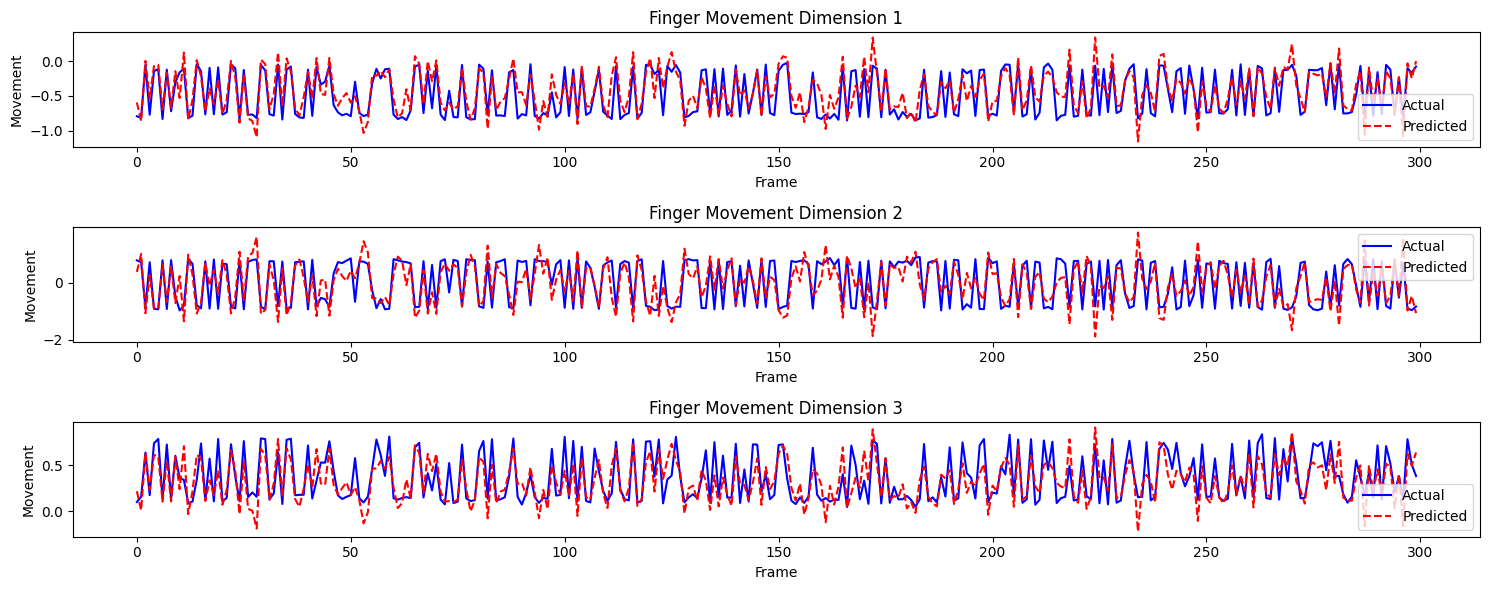

In [ ]:
import matplotlib.pyplot as plt

# 🧠 Predict finger movements from EEG signals
y_pred = model.predict(X_test)

# 🎯 Plot actual vs predicted for the first N frames
N = 300  # you can increase or decrease as needed
plt.figure(figsize=(15, 6))

# Plot for each of the 3 finger movement dimensions
for i in range(3):
    plt.subplot(3, 1, i + 1)
    plt.plot(y_test[:N, i], label='Actual', color='blue')
    plt.plot(y_pred[:N, i], label='Predicted', color='red', linestyle='dashed')
    plt.title(f'Finger Movement Dimension {i+1}')
    plt.xlabel('Frame')
    plt.ylabel('Movement')
    plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

for i in range(3):
    mse = mean_squared_error(y_test[:, i], y_pred[:, i])
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    print(f"Dimension {i+1} - MSE: {mse:.4f}, R²: {r2:.4f}")



Dimension 1 - MSE: 0.0377, R²: 0.6418
Dimension 2 - MSE: 0.2304, R²: 0.6221
Dimension 3 - MSE: 0.0295, R²: 0.5628


### Save CNN results


In [ ]:
save_result("cnn", model, history, y_test, y_pred, training_seconds)


In [ ]:
import time

for i in range(50):
    input_sample = X_test[i:i+1]
    pred = model.predict(input_sample)
    print(f"Frame {i+1} | Predicted: {pred[0]} | Actual: {y_test[i]}")
    time.sleep(0.1)  # simulate 10Hz EEG stream


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Frame 1 | Predicted: [-0.5958195   0.38523746  0.2179795 ] | Actual: [-0.79352252  0.79128579  0.10099506]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Frame 2 | Predicted: [-0.8609768   1.0187316   0.01149157] | Actual: [-0.81586879  0.72763335  0.15747805]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Frame 3 | Predicted: [ 0.00193831 -1.0722904   0.6349206 ] | Actual: [-0.0549194  -0.8490494   0.63724392]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
Frame 4 | Predicted: [-0.5443362  0.2750811  0.2347541] | Actual: [-0.77162911  0.72522842  0.17538028]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Frame 5 | Predicted: [-0.07324587 -0.8866519   0.61198187] | Actual: [-0.14508259 -0.91807417  0.73846224]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
Frame 6 | Predicted: [-0.05451861 -0.93074375  0.5977744 ] | Actual: [-0.11674441 -0.93175021  0.78546563]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Frame 7 | Predicted: [-0.69495094  0.64374095  0.1053998 ] | Actual: [-0.83258467  0.79324

**model update CNN+BiLSTM Model**

In [ ]:
# Remove last dimension (channel = 1) to get shape (samples, 128, 32)
X_train_seq = X_train.squeeze(-1)
X_test_seq = X_test.squeeze(-1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, Bidirectional, LSTM
from tensorflow.keras.layers import Dropout, Dense, InputLayer

model = Sequential([
    InputLayer(input_shape=(128, 32)),

    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.3),

    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(3)  # Output for 3 finger values
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,347 (239.64 KB)

 Trainable params: 61,283 (239.39 KB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
training_started = time.perf_counter()  # Runtime measurement only
history = model.fit(X_train_seq, y_train, epochs=20, batch_size=64,
                    validation_data=(X_test_seq, y_test))

training_seconds = time.perf_counter() - training_started


Epoch 1/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 63s 190ms/step - loss: 0.1783 - mae: 0.3044 - val_loss: 0.1830 - val_mae: 0.2488
Epoch 2/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 80s 186ms/step - loss: 0.0699 - mae: 0.1719 - val_loss: 0.0997 - val_mae: 0.1743
Epoch 3/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 55s 182ms/step - loss: 0.0603 - mae: 0.1546 - val_loss: 0.3953 - val_mae: 0.4259
Epoch 4/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 84s 188ms/step - loss: 0.0668 - mae: 0.1581 - val_loss: 0.2652 - val_mae: 0.3691
Epoch 5/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 81s 185ms/step - loss: 0.0614 - mae: 0.1495 - val_loss: 0.0626 - val_mae: 0.1457
Epoch 6/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 82s 186ms/step - loss: 0.0511 - mae: 0.1357 - val_loss: 0.0888 - val_mae: 0.1824
Epoch 7/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 54s 181ms/step - loss: 0.0447 - mae: 0.1274 - val_loss: 0.0602 - val_mae: 0.1308
Epoch 8/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 83s 185ms/step - loss: 0.0436 - mae: 0.1252 - val_loss: 0.0536 - val_mae: 0.1482
Epoch 9/20
301/301 ━━━━━━━━━━━━━

In [ ]:
y_pred = model.predict(X_test_seq)

from sklearn.metrics import mean_squared_error, r2_score

for i in range(3):
    mse = mean_squared_error(y_test[:, i], y_pred[:, i])
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    print(f"Dimension {i+1} - MSE: {mse:.4f}, R²: {r2:.4f}")


151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step
Dimension 1 - MSE: 0.0284, R²: 0.7303
Dimension 2 - MSE: 0.1818, R²: 0.7018
Dimension 3 - MSE: 0.0217, R²: 0.6783


### Save CNN–BiLSTM results


In [ ]:
save_result("cnn_bilstm", model, history, y_test, y_pred, training_seconds)


In [ ]:
model.save("eeg_glove_model.h5")


In [ ]:
from google.colab import files
files.download("eeg_glove_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import zipfile
import os

zip_path = "/content/way-eeg-gal-clean.zip"
extract_path = "/content/way_eeg_clean"

# Extract if folder not already extracted
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("Extraction complete.")


Extraction complete.


In [ ]:
import os

data_dir = "/content/way_eeg_clean"
files = os.listdir(data_dir)
print(files)


['kin_P12.mat', 'P4_AllLifts.mat', 'P2_AllLifts.mat', 'P2_S1.mat', 'eeg_P5.mat', 'eeg_P6.mat', 'kin_P2.mat', 'P9_AllLifts.mat', 'eeg_P7.mat', 'eeg_P9.mat', 'session_start_P7.mat', 'kin_P3.mat', 'eeg_P1.mat', 'eeg_P10.mat', 'session_start_P6.mat', 'P5_AllLifts.mat', 'kin_P1.mat', 'eeg_P8.mat', 'eeg_P2.mat', 'P6_AllLifts.mat', 'session_start_P1.mat', 'session_start_P2.mat', 'session_start_P4.mat', 'P7_AllLifts.mat', 'kin_P7.mat', 'eeg_P55.mat', 'eeg_P12.mat', 'P8_AllLifts.mat', 'eeg_P3.mat', 'kin_P4.mat', 'kin_P10.mat', 'P1_AllLifts.mat', 'kin_P8.mat', 'session_start_P10.mat', 'eeg_P11.mat', 'session_start_P3.mat', 'session_start_P8.mat', 'session_start_P5.mat', 'P3_AllLifts.mat', 'session_start_P12.mat', 'kin_P9.mat', 'session_start_P11.mat', 'P11_AllLifts.mat', 'session_start_P9.mat', 'session_start_P55.mat', 'kin_P11.mat', 'eeg_P4.mat', 'kin_P5.mat', 'kin_P6.mat', 'kin_P55.mat', 'P10_AllLifts.mat', 'P12_AllLifts.mat']


In [ ]:
import scipy.io
import numpy as np

# Load EEG and kinematic (glove) data for subject P2
eeg_data = scipy.io.loadmat('/content/way_eeg_clean/eeg_P2.mat')
glove_data = scipy.io.loadmat('/content/way_eeg_clean/kin_P2.mat')

# Print keys to understand structure
print("EEG keys:", eeg_data.keys())
print("Glove keys:", glove_data.keys())


EEG keys: dict_keys(['__header__', '__version__', '__globals__', 'eeg'])
Glove keys: dict_keys(['__header__', '__version__', '__globals__', 'kin'])


In [ ]:
# Assuming 'eeg' and 'kin' are the correct keys (adjust if needed)
X_raw = eeg_data['eeg']      # shape: (samples, channels)
y_raw = glove_data['kin']    # shape: (samples, 5)

# Normalize inputs (EEG)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Make sequences (e.g., past 64 samples for each target)
def create_sequences(X, y, window_size=64, step=1):
    X_seq, y_seq = [], []
    for i in range(0, len(X) - window_size, step):
        X_seq.append(X[i:i + window_size])
        y_seq.append(y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_raw)

print("Shape of input sequence:", X_seq.shape)
print("Shape of target:", y_seq.shape)


Shape of input sequence: (0,)
Shape of target: (0,)


In [ ]:
from google.colab import files
files.upload()  # Select eeg_glove_model.h5

Saving eeg_glove_model.h5 to eeg_glove_model.h5


{'eeg_glove_model.h5': b'\x89HDF\r\n\x1a\n\x00\x00\x00\x00\x00\x08\x08\x00\x04\x00\x10\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xff\xff\xff\xff\xff\xff\xff\xa0&\x0c\x00\x00\x00\x00\x00\xff\xff\xff\xff\xff\xff\xff\xff\x00\x00\x00\x00\x00\x00\x00\x00`\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x88\x00\x00\x00\x00\x00\x00\x00\xa8\x02\x00\x00\x00\x00\x00\x00\x01\x00\x06\x00\x01\x00\x00\x00\x18\x00\x00\x00\x00\x00\x00\x00\x10\x00\x10\x00\x00\x00\x00\x00 \x03\x00\x00\x00\x00\x00\x00P\x01\x00\x00\x00\x00\x00\x00TREE\x00\x00\x01\x00\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\x00\x00\x00\x00\x00\x00\x00\x00\x00(\x00\x00\x00\x00\x00\x00\x18\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\

In [ ]:
from tensorflow.keras.models import load_model

# Load without compiling
model = load_model('/content/eeg_glove_model.h5', compile=False)

# Optional: model.summary()


In [ ]:
# Assuming 'eeg' and 'kin' are the correct keys (adjust if needed)
X_raw = eeg_data['eeg']      # shape: (samples, channels)
y_raw = glove_data['kin']    # shape: (samples, 5)

# Normalize inputs (EEG)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Make sequences (e.g., past 64 samples for each target)
def create_sequences(X, y, window_size=64, step=1):
    X_seq, y_seq = [], []
    # Ensure there's enough data for at least one window
    if len(X) <= window_size:
        print(f"Warning: Data length ({len(X)}) is not sufficient for window size ({window_size}). Cannot create sequences.")
        return np.array(X_seq), np.array(y_seq) # Return empty arrays

    for i in range(0, len(X) - window_size, step):
        X_seq.append(X[i:i + window_size])
        y_seq.append(y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

# Check data length before creating sequences
window_size = 64 # Define window_size here as well for the check
if len(X_scaled) > window_size:
    X_seq, y_seq = create_sequences(X_scaled, y_raw, window_size=window_size)
    print("Shape of input sequence:", X_seq.shape)
    print("Shape of target:", y_seq.shape)
else:
    X_seq = np.array([]) # Initialize as empty arrays if not enough data
    y_seq = np.array([])
    print(f"Not enough data ({len(X_scaled)} samples) to create sequences with window size {window_size}.")


Not enough data (32 samples) to create sequences with window size 64.


In [ ]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model
from google.colab import files
import os

# --- Data Loading and Preprocessing for Subject P2 ---

# Ensure the data is extracted
zip_path = "/content/way-eeg-gal-clean.zip"
extract_path = "/content/way_eeg_clean"

# Extract if folder not already extracted
if not os.path.exists(extract_path):
    print("Extracting data...")
    import zipfile
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete.")
else:
    print("Data already extracted.")


# Load EEG and kinematic (glove) data for subject P2
# Make sure the files exist after extraction
eeg_p2_path = os.path.join(extract_path, 'eeg_P2.mat')
kin_p2_path = os.path.join(extract_path, 'kin_P2.mat')

if not os.path.exists(eeg_p2_path) or not os.path.exists(kin_p2_path):
    print(f"Error: Data files not found at {extract_path}. Please check extraction.")
else:
    print(f"Loading data for P2 from {extract_path}...")
    eeg_data = scipy.io.loadmat(eeg_p2_path)
    glove_data = scipy.io.loadmat(kin_p2_path)

    # Assuming 'eeg' and 'kin' are the correct keys (adjust if needed)
    # You printed keys in a previous cell, confirm they are correct if needed.
    X_raw = eeg_data.get('eeg')
    y_raw = glove_data.get('kin')

    if X_raw is None or y_raw is None:
        print("Error: 'eeg' or 'kin' key not found in .mat files.")
    else:
        # Normalize inputs (EEG) using StandardScaler
        # Note: We fit the scaler *only* on the P2 data here, which might not be ideal
        # for a real-world scenario where you'd use a scaler fitted on training data.
        # For simulation purposes with P2 data specifically, this is acceptable.
        print("Normalizing EEG data...")
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_raw)

        # Make sequences (e.g., past window_size samples for each target)
        def create_sequences(X, y, window_size=64, step=1):
            X_seq, y_seq = [], []
            # Ensure there's enough data for at least one window
            if len(X) <= window_size:
                print(f"Warning: Data length ({len(X)}) is not sufficient for window size ({window_size}). Cannot create sequences.")
                return np.array(X_seq), np.array(y_seq) # Return empty arrays

            for i in range(0, len(X) - window_size + 1, step): # Added +1 to include the last possible window
                X_seq.append(X[i:i + window_size])
                y_seq.append(y[i + window_size -1]) # Target is the last sample of the window
            return np.array(X_seq), np.array(y_seq)

        # Check data length before creating sequences
        window_size = 64 # Define window_size for sequence creation
        step = 1 # Define step for sequence creation

        if len(X_scaled) > window_size:
            print(f"Creating sequences with window size {window_size}...")
            X_seq, y_seq = create_sequences(X_scaled, y_raw, window_size=window_size, step=step)
            print("Shape of input sequence:", X_seq.shape)
            print("Shape of target:", y_seq.shape)

            # --- Model Loading and Prediction ---

            # Upload the model file if it's not already in the environment (e.g., after restarting)
            if not os.path.exists("eeg_glove_model.h5"):
                print("Uploading model file...")
                uploaded = files.upload()
                if "eeg_glove_model.h5" not in uploaded:
                     print("Error: eeg_glove_model.h5 not uploaded.")
                else:
                    print("Model file uploaded.")
            else:
                print("Model file already exists.")


            if os.path.exists("eeg_glove_model.h5"):
                print("Loading the trained model...")
                # Load without compiling as we only need it for inference
                model = load_model("eeg_glove_model.h5", compile=False)
                print("Model loaded successfully.")

                # --- Simulation and Visualization ---

                # Predict first N samples for simulation
                N = 50 # Number of frames to simulate and plot
                if X_seq.shape[0] >= N:
                    print(f"Predicting finger movements for the first {N} frames...")
                    y_pred = model.predict(X_seq[:N])
                    y_true = y_seq[:N]

                    print("Prediction complete. Plotting results...")

                    # Plot the true vs predicted glove positions for each finger
                    # Note: The model was trained on data where y had shape (samples, 3)
                    # but the P2 data y_raw has shape (samples, 5).
                    # We need to decide which 3 dimensions of y_raw correspond to the model's output.
                    # Assuming the model output matches the first 3 dimensions of y_raw for visualization.
                    # Adjust indices [0, 1, 2] if the model was trained on different fingers.
                    num_fingers_to_plot = min(y_pred.shape[1], y_true.shape[1], 3) # Plot up to 3 fingers or less if shapes differ

                    plt.figure(figsize=(15, num_fingers_to_plot * 3)) # Adjust figure size based on number of plots

                    for i in range(num_fingers_to_plot):
                        plt.subplot(num_fingers_to_plot, 1, i + 1)
                        plt.plot(y_true[:, i], label='Actual', color='blue')
                        plt.plot(y_pred[:, i], label='Predicted', color='red', linestyle='dashed')
                        plt.ylabel(f'Finger {i+1}') # Label fingers 1, 2, 3...
                        plt.legend()
                        plt.title(f'Finger Movement Simulation - Dimension {i+1}') # Title for each subplot

                    plt.xlabel('Time Step')
                    plt.suptitle("Prosthetic Arm Finger Movement Simulation (Subject P2 Data)")
                    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
                    plt.show()

                    # Optional: Print some comparison metrics
                    from sklearn.metrics import mean_squared_error, r2_score
                    print("\nPerformance Metrics (First {} frames):".format(N))
                    for i in range(num_fingers_to_plot):
                         mse = mean_squared_error(y_true[:, i], y_pred[:, i])
                         r2 = r2_score(y_true[:, i], y_pred[:, i])
                         print(f"Dimension {i+1} - MSE: {mse:.4f}, R²: {r2:.4f}")


                elif X_seq.shape[0] > 0:
                     print(f"Warning: Not enough sequences ({X_seq.shape[0]}) to plot the first {N} frames.")
                     # You could plot all available sequences if desired
                     # y_pred = model.predict(X_seq)
                     # y_true = y_seq
                     # ... plot all available data ...
                else:
                    print("No sequences were created from P2 data.")

            else:
                 print("Model file 'eeg_glove_model.h5' not found. Cannot perform simulation.")


        else:
            print(f"Not enough data ({len(X_scaled)} samples) to create sequences with window size {window_size}. Cannot perform simulation.")

Data already extracted.
Loading data for P2 from /content/way_eeg_clean...
Normalizing EEG data...
Not enough data (32 samples) to create sequences with window size 64. Cannot perform simulation.


In [ ]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model
from google.colab import files
import os
# Assuming X_test_seq and y_test from the P1 training section are still in memory
# If you restarted the notebook, you'll need to re-run the cells up to where
# X_test_seq and y_test are created.

# --- Model Loading and Prediction ---

# Upload the model file if it's not already in the environment (e.g., after restarting)
if not os.path.exists("eeg_glove_model.h5"):
    print("Uploading model file...")
    uploaded = files.upload()
    if "eeg_glove_model.h5" not in uploaded:
         print("Error: eeg_glove_model.h5 not uploaded.")
    else:
        print("Model file uploaded.")
else:
    print("Model file already exists.")


if os.path.exists("eeg_glove_model.h5"):
    print("Loading the trained model...")
    # Load without compiling as we only need it for inference
    model = load_model("eeg_glove_model.h5", compile=False)
    print("Model loaded successfully.")

    # --- Simulation and Visualization using P1 Test Data ---

    # Use a subset of the existing P1 test data for simulation
    # This assumes X_test_seq and y_test from the training phase are available
    if 'X_test_seq' in locals() and 'y_test' in locals() and X_test_seq.shape[0] > 0:
        print("Using P1 test data for simulation...")

        # Predict first N samples for simulation
        N = 50 # Number of frames to simulate and plot
        if X_test_seq.shape[0] >= N:
            print(f"Predicting finger movements for the first {N} frames...")
            y_pred = model.predict(X_test_seq[:N])
            y_true = y_test[:N]

            print("Prediction complete. Plotting results...")

            # Plot the true vs predicted glove positions for each finger
            # The model output shape is (samples, 3) based on your training.
            num_fingers_to_plot = y_pred.shape[1] # Should be 3

            plt.figure(figsize=(15, num_fingers_to_plot * 3)) # Adjust figure size based on number of plots

            for i in range(num_fingers_to_plot):
                plt.subplot(num_fingers_to_plot, 1, i + 1)
                plt.plot(y_true[:, i], label='Actual (P1 Test Data)', color='blue')
                plt.plot(y_pred[:, i], label='Predicted (P1 Test Data)', color='red', linestyle='dashed')
                plt.ylabel(f'Finger {i+1}') # Label fingers 1, 2, 3...
                plt.legend()
                plt.title(f'Finger Movement Simulation - Dimension {i+1}') # Title for each subplot

            plt.xlabel('Time Step')
            plt.suptitle("Prosthetic Arm Finger Movement Simulation (Using P1 Test Data)")
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
            plt.show()

            # Optional: Print some comparison metrics
            from sklearn.metrics import mean_squared_error, r2_score
            print("\nPerformance Metrics (First {} frames on P1 Test Data):".format(N))
            for i in range(num_fingers_to_plot):
                 mse = mean_squared_error(y_true[:, i], y_pred[:, i])
                 r2 = r2_score(y_true[:, i], y_pred[:, i])
                 print(f"Dimension {i+1} - MSE: {mse:.4f}, R²: {r2:.4f}")

        elif X_test_seq.shape[0] > 0:
             print(f"Warning: Not enough sequences in P1 test data ({X_test_seq.shape[0]}) to plot the first {N} frames.")
             # You could plot all available sequences if desired
             # y_pred = model.predict(X_test_seq)
             # y_true = y_test
             # ... plot all available data ...
        else:
            print("P1 test data (X_test_seq) is empty. Cannot perform simulation.")

    else:
        print("P1 test data (X_test_seq, y_test) not found or is empty. Please ensure you have run the training cells.")


else:
     print("Model file 'eeg_glove_model.h5' not found. Cannot perform simulation.")

Model file already exists.
Loading the trained model...
Model loaded successfully.
P1 test data (X_test_seq, y_test) not found or is empty. Please ensure you have run the training cells.


In [ ]:
# Re-run these cells from your notebook to recreate X_test_seq and y_test

# Load EEG and glove (kinematics) data for subject P1
# Make sure you are in the correct directory if needed
import scipy.io as sio
import numpy as np
from sklearn.model_selection import train_test_split

eeg = sio.loadmat("way_eeg_clean/eeg_P1.mat")
glove = sio.loadmat("way_eeg_clean/kin_P1.mat")

# Access EEG and glove signals using correct keys
eeg_data = eeg['eeg']         # shape: (samples, channels)
glove_data = glove['kin']     # shape: (samples, 22) # Note: Original kin_P1 had 22 features, but your model outputs 3. Make sure your y_test reflects the 3 fingers used for training.

# Check shapes (optional, but good practice)
print("EEG shape (before transpose):", eeg_data.shape)
print("Glove (kinematics) shape:", glove_data.shape)

# --- Correcting the transpose logic based on your working P1 training code ---
# Your initial code loaded eeg as (samples, channels) (1538345, 32)
# Then you did eeg_data = eeg_data.T which made it (32, 1538345).
# This transpose doesn't make sense for time-series windowing where samples are the first dimension.
# Let's use the original shape (samples, channels) for windowing.

eeg_data_orig = eeg['eeg'] # (1538345, 32)
glove_data_orig = glove['kin'] # (1538345, 22)


# Normalize P1 data (using the original normalization from your working code)
# Apply normalization to the original (samples, channels) shape.
# Correcting the typo 'e' to 'eeg'
eeg_data_normalized_p1 = (eeg_data_orig - np.min(eeg_data_orig)) / (np.max(eeg_data_orig) - np.min(eeg_data_orig))
eeg_data_normalized_p1 = eeg_data_normalized_p1 * 2 - 1

# Normalize Glove data (using the original normalization)
glove_data_normalized_p1 = (glove_data_orig - np.min(glove_data_orig)) / (np.max(glove_data_orig) - np.min(glove_data_orig))
glove_data_normalized_p1 = glove_data_normalized_p1 * 2 - 1

# Create sequences for P1 using the normalized data (samples, channels)
window_size = 128  # 0.25 seconds window at 512Hz
stride = 64        # 50% overlap

X_p1 = [] # Renaming to avoid confusion
y_p1 = [] # Renaming to avoid confusion

# Ensure there's enough data for at least one window
if len(eeg_data_normalized_p1) <= window_size:
    print(f"Warning: P1 Data length ({len(eeg_data_normalized_p1)}) is not sufficient for window size ({window_size}). Cannot create sequences.")
else:
    for i in range(0, len(eeg_data_normalized_p1) - window_size, stride):
        X_p1.append(eeg_data_normalized_p1[i:i + window_size]) # shape (window_size, channels)
        # Assuming your model was trained to predict only the first 3 finger dimensions from the 22 glove dimensions
        y_p1.append(glove_data_normalized_p1[i + window_size, :3]) # Target is the sample *after* the window, first 3 dimensions

    X_p1 = np.array(X_p1)  # shape: (num_samples, window_size, channels) -> (num_samples, 128, 32)
    y_p1 = np.array(y_p1)  # shape: (num_samples, 3)


    # Split into train/test for P1 data
    # Use the 3-finger targets for splitting
    X_train, X_test, y_train, y_test = train_test_split(X_p1, y_p1, test_size=0.2, random_state=42)

    print("P1 Train shape:", X_train.shape, y_train.shape)
    print("P1 Test shape:", X_test.shape, y_test.shape)

    # Prepare P1 test data for the CNN+BiLSTM model input shape
    # The CNN+BiLSTM model expected (samples, 128, 32)
    # X_test currently has shape (num_test_samples, 128, 32)
    # This matches the expected input shape.

    # Let's set X_test_seq = X_test as the input shape matches.
    X_test_seq = X_test
    # y_test is already the correct shape (num_test_samples, 3)


    print("P1 Test shape (for simulation):", X_test_seq.shape, y_test.shape)

# --- Now proceed to the simulation cell ---

EEG shape (before transpose): (32, 1538345)
Glove (kinematics) shape: (1538345, 3)


In [ ]:
# Re-run these cells from your notebook to recreate X_test_seq and y_test

# Load EEG and glove (kinematics) data for subject P1
# Make sure you are in the correct directory if needed
import scipy.io as sio
import numpy as np
from sklearn.model_selection import train_test_split

eeg = sio.loadmat("way_eeg_clean/eeg_P1.mat")
glove = sio.loadmat("way_eeg_clean/kin_P1.mat")

# Access EEG and glove signals using correct keys and observe shapes
eeg_raw_loaded = eeg['eeg']         # shape from print: (32, 1538345) --> (channels, samples)
glove_raw_loaded = glove['kin']     # shape from print: (1538345, 3) --> (samples, features=3)

print("EEG shape (as loaded):", eeg_raw_loaded.shape)
print("Glove (kinematics) shape (as loaded):", glove_raw_loaded.shape)

# --- Correcting preprocessing based on observed shapes ---

# Transpose EEG data to be (samples, channels) for windowing
eeg_data_correct_shape = eeg_raw_loaded.T # Should now be (1538345, 32)

# Glove data is already in (samples, features=3) shape, so no slicing needed for y
glove_data_correct_shape = glove_raw_loaded # Shape: (1538345, 3)

# Normalize P1 data (using the original normalization logic)
# Apply normalization to the (samples, channels) shape EEG data
eeg_data_normalized_p1 = (eeg_data_correct_shape - np.min(eeg_data_correct_shape)) / (np.max(eeg_data_correct_shape) - np.min(eeg_data_correct_shape))
eeg_data_normalized_p1 = eeg_data_normalized_p1 * 2 - 1

# Normalize Glove data (using the original normalization)
# Apply normalization to the (samples, 3) shape Glove data
glove_data_normalized_p1 = (glove_data_correct_shape - np.min(glove_data_correct_shape)) / (np.max(glove_data_correct_shape) - np.min(glove_data_correct_shape))
glove_data_normalized_p1 = glove_data_normalized_p1 * 2 - 1

# Create sequences for P1 using the normalized data (samples, channels)
window_size = 128  # 0.25 seconds window at 512Hz
stride = 64        # 50% overlap

X_p1 = [] # Renaming to avoid confusion
y_p1 = [] # Renaming to avoid confusion

# Check data length before creating sequences
# Use the correctly shaped EEG data for length check
if len(eeg_data_normalized_p1) <= window_size:
    print(f"Warning: P1 Data length ({len(eeg_data_normalized_p1)}) is not sufficient for window size ({window_size}). Cannot create sequences.")
else:
    print(f"Creating sequences with window size {window_size}...")
    for i in range(0, len(eeg_data_normalized_p1) - window_size, stride):
        X_p1.append(eeg_data_normalized_p1[i:i + window_size, :]) # shape (window_size, channels) - Take all 32 channels
        # Target is the sample *after* the window, using all 3 dimensions from the glove data
        y_p1.append(glove_data_normalized_p1[i + window_size, :]) # shape (3,)

    X_p1 = np.array(X_p1)  # shape: (num_samples, window_size, channels) -> (num_samples, 128, 32)
    y_p1 = np.array(y_p1)  # shape: (num_samples, 3)


    # Split into train/test for P1 data
    # y_p1 already has the correct shape (num_samples, 3)
    X_train, X_test, y_train, y_test = train_test_split(X_p1, y_p1, test_size=0.2, random_state=42)

    print("P1 Train shape:", X_train.shape, y_train.shape)
    print("P1 Test shape:", X_test.shape, y_test.shape)

    # Prepare P1 test data for the CNN+BiLSTM model input shape
    # The CNN+BiLSTM model expected (samples, 128, 32)
    # X_test currently has shape (num_test_samples, 128, 32)
    # This matches the expected input shape.

    # Let's set X_test_seq = X_test as the input shape matches.
    X_test_seq = X_test
    # y_test is already the correct shape (num_test_samples, 3)


    print("P1 Test shape (for simulation):", X_test_seq.shape, y_test.shape)

# --- Now proceed to the simulation cell ---

EEG shape (as loaded): (32, 1538345)
Glove (kinematics) shape (as loaded): (1538345, 3)
Creating sequences with window size 128...
P1 Train shape: (19228, 128, 32) (19228, 3)
P1 Test shape: (4807, 128, 32) (4807, 3)
P1 Test shape (for simulation): (4807, 128, 32) (4807, 3)


Model file already exists.
Loading the trained model...
Model loaded successfully.
Using P1 test data for simulation...
Predicting finger movements for the first 50 frames...
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 895ms/step
Prediction complete. Plotting results...


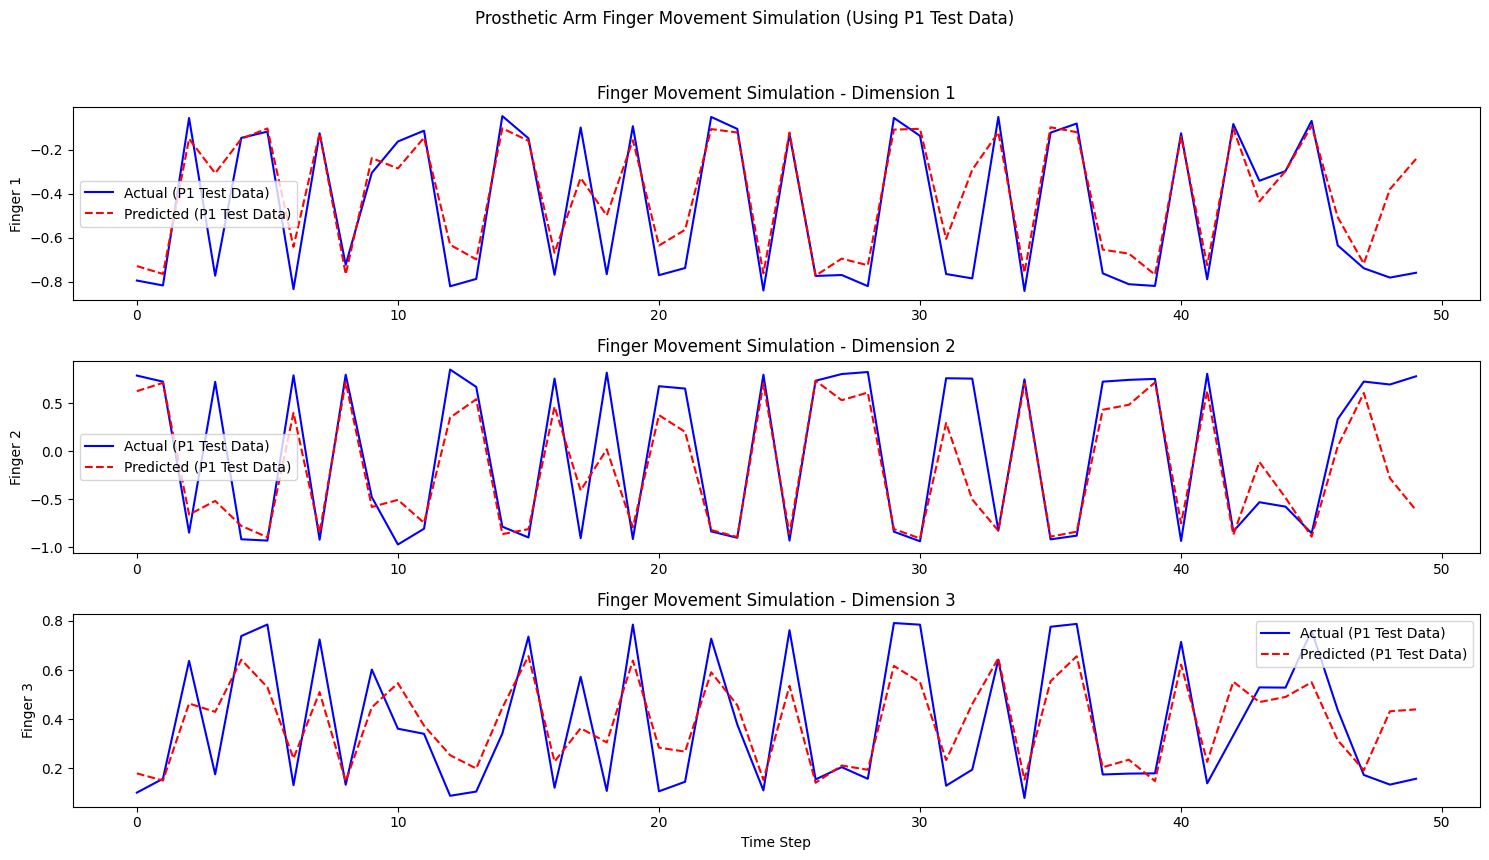


Performance Metrics (First 50 frames on P1 Test Data):
Dimension 1 - MSE: 0.0266, R²: 0.7584
Dimension 2 - MSE: 0.1792, R²: 0.7196
Dimension 3 - MSE: 0.0226, R²: 0.6866


In [ ]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model
from google.colab import files
import os
# Assuming X_test_seq and y_test from the P1 training section are still in memory
# If you restarted the notebook, you'll need to re-run the cells up to where
# X_test_seq and y_test are created.

# --- Model Loading and Prediction ---

# Upload the model file if it's not already in the environment (e.g., after restarting)
if not os.path.exists("eeg_glove_model.h5"):
    print("Uploading model file...")
    uploaded = files.upload()
    if "eeg_glove_model.h5" not in uploaded:
         print("Error: eeg_glove_model.h5 not uploaded.")
    else:
        print("Model file uploaded.")
else:
    print("Model file already exists.")


if os.path.exists("eeg_glove_model.h5"):
    print("Loading the trained model...")
    # Load without compiling as we only need it for inference
    model = load_model("eeg_glove_model.h5", compile=False)
    print("Model loaded successfully.")

    # --- Simulation and Visualization using P1 Test Data ---

    # Use a subset of the existing P1 test data for simulation
    # This assumes X_test_seq and y_test from the training phase are available
    if 'X_test_seq' in locals() and 'y_test' in locals() and X_test_seq.shape[0] > 0:
        print("Using P1 test data for simulation...")

        # Predict first N samples for simulation
        N = 50 # Number of frames to simulate and plot
        if X_test_seq.shape[0] >= N:
            print(f"Predicting finger movements for the first {N} frames...")
            y_pred = model.predict(X_test_seq[:N])
            y_true = y_test[:N]

            print("Prediction complete. Plotting results...")

            # Plot the true vs predicted glove positions for each finger
            # The model output shape is (samples, 3) based on your training.
            num_fingers_to_plot = y_pred.shape[1] # Should be 3

            plt.figure(figsize=(15, num_fingers_to_plot * 3)) # Adjust figure size based on number of plots

            for i in range(num_fingers_to_plot):
                plt.subplot(num_fingers_to_plot, 1, i + 1)
                plt.plot(y_true[:, i], label='Actual (P1 Test Data)', color='blue')
                plt.plot(y_pred[:, i], label='Predicted (P1 Test Data)', color='red', linestyle='dashed')
                plt.ylabel(f'Finger {i+1}') # Label fingers 1, 2, 3...
                plt.legend()
                plt.title(f'Finger Movement Simulation - Dimension {i+1}') # Title for each subplot

            plt.xlabel('Time Step')
            plt.suptitle("Prosthetic Arm Finger Movement Simulation (Using P1 Test Data)")
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
            plt.show()

            # Optional: Print some comparison metrics
            from sklearn.metrics import mean_squared_error, r2_score
            print("\nPerformance Metrics (First {} frames on P1 Test Data):".format(N))
            for i in range(num_fingers_to_plot):
                 mse = mean_squared_error(y_true[:, i], y_pred[:, i])
                 r2 = r2_score(y_true[:, i], y_pred[:, i])
                 print(f"Dimension {i+1} - MSE: {mse:.4f}, R²: {r2:.4f}")

        elif X_test_seq.shape[0] > 0:
             print(f"Warning: Not enough sequences in P1 test data ({X_test_seq.shape[0]}) to plot the first {N} frames.")
             # You could plot all available sequences if desired
             # y_pred = model.predict(X_test_seq)
             # y_true = y_test
             # ... plot all available data ...
        else:
            print("P1 test data (X_test_seq) is empty. Cannot perform simulation.")

    else:
        print("P1 test data (X_test_seq, y_test) not found or is empty. Please ensure you have run the training cells.")


else:
     print("Model file 'eeg_glove_model.h5' not found. Cannot perform simulation.")